# ViTucano-1b5 LoRA fine-tuning (Kaggle)
GPU on, Internet on, Secret `HF_API_KEY`. Run cells 1-3 once, then cell 4 with `SMOKE=True`, then `SMOKE=False`.
For the real run use **Save Version -> Save & Run All**. Config lives in `vlm/src/config/config_vitucano.yml`.

In [71]:
!pip install -q "protobuf>=6.31.1,<7"
!pip install -q -U bitsandbytes

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
open-clip-torch 2.22.0 requires protobuf<4, but you have protobuf 6.33.6 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2024.9.0 which is incompatible.


In [72]:
SMOKE = True       # True: 20 train / 10 test images (~3 min)
TRAIN_IMAGES = 2000   # real run size (None = all 5000, ~5-8h)
PUSH = True           # push adapter to the HF Hub (real run only)
BRANCH = "kaggle-vitucano"

In [73]:
import os
#keyword:
os.environ["HF_API_KEY"] = "_"
os.environ.update(USE_TF="0", USE_FLAX="0", CUDA_VISIBLE_DEVICES="0", PYTHONUNBUFFERED="1")

In [74]:
import os

# Se estiver rodando no Google Colab, cria o diretório de compatibilidade
if not os.path.exists('/kaggle/working'):
    os.makedirs('/kaggle/working', exist_ok=True)

%cd /kaggle/working
!git clone -q -b {BRANCH} https://github.com/LukaOliver-S/transformer-caption-ptbr.git 2>/dev/null || true
%cd /kaggle/working/transformer-caption-ptbr/vlm
!pip install -q transformers==4.45.2 peft==0.10.0 accelerate==1.0.1 datasets==3.0.2 evaluate==0.4.3 rouge_score bert_score nltk wandb python-dotenv huggingface_hub==0.26.1 open_clip_torch==2.22 openai==1.59.8 pyyaml tqdm
!pip install -q "protobuf>=5.29,<6"
with open(".env", "w") as f:
    f.write(f'HF_API_KEY="{os.environ["HF_API_KEY"]}"\n')
    if "WANDB_API_KEY" in os.environ: f.write(f'WANDB_API_KEY="{os.environ["WANDB_API_KEY"]}"\n')

/kaggle/working
/kaggle/working/transformer-caption-ptbr/vlm
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.75.5 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 3.20.3 which is incompatible.
tensorboard 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.3 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grpc-google-iam-v1 0.14.5 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 3.20.3 which is incompatible.
google-cloud-storage-control 1.15.0 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 3.20.3 which is incompatible.
google-cloud-datastore 2.26.1 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 3.20.3 which is incompatible.
google-cloud-dataproc 5.30.0 requires protobuf<8.0.0,>=6.33.5, but you have protob

In [75]:
%cd /kaggle/working/transformer-caption-ptbr
!git pull origin kaggle-vitucano
!grep -n bnb_4bit vlm/src/train_vitucano.py


/kaggle/working/transformer-caption-ptbr
From https://github.com/LukaOliver-S/transformer-caption-ptbr
 * branch            kaggle-vitucano -> FETCH_HEAD
Updating 87cdb6c..79a33bc
error: Your local changes to the following files would be overwritten by merge:
	vlm/src/config/config_vitucano_8bits.yaml
Please commit your changes or stash them before you merge.
Aborting
53:            bnb_4bit_quant_type="nf4",
54:            bnb_4bit_compute_dtype=dtype, #fp16 on specific GPUs


In [76]:
import shutil
%cd /kaggle/working/transformer-caption-ptbr/vlm/src
shutil.rmtree("../models", ignore_errors=True)   # clean run. To RESUME an interrupted run, comment this out.
flags = "--train-images 20 --test-images 10 --monitoring-steps 10 --no-push" if SMOKE else         (f"--train-images {TRAIN_IMAGES} " if TRAIN_IMAGES else "") + ("" if PUSH else "--no-push")
!python -u train_vitucano.py {flags}

/kaggle/working/transformer-caption-ptbr/vlm/src
/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
AAC metrics is not available, skipping...

Precision: fp16
{'dataset': 'flickr30k_pt',
 'model_id': 'TucanoBR/ViTucano-1b5-v1',
 'monitoring_steps': 10,
 'push_to_hub': False}
trainable params: 15,601,664 || all params: 1,550,433,344 || trainable%: 1.0062776358865513

Dataset
	Train: 20
	Val: 10
	Test: 10

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
{'loss': 6.4504, 'grad_norm': 15.270621299743652, 'learning_rate': 7.6e-05, 'epoch': 0.4}
{'loss': 2.3407, 'grad_norm': 3.956585168838501, 'learning_ra

In [77]:
import os
import pandas as pd

# Caminho absoluto ou relativo corrigido
base = "/kaggle/working/transformer-caption-ptbr/vlm/models/vitucano-1b-ft/flickr30k_pt/results/flickr30k_pt"

metrics_file = f"{base}/sample_eval_metrics.csv"
preds_file = f"{base}/predictions.json"

if os.path.exists(metrics_file) and os.path.exists(preds_file):
    print("=== Métricas de Avaliação ===")
    print(pd.read_csv(metrics_file).T.to_string())

    print("\n=== Amostra de Predições ===")
    print(pd.read_json(preds_file, lines=True)[["prediction_text", "label_text"]].head(6).to_string())
else:
    print("Erro: Os resultados do treinamento não foram encontrados.")
    print("Isso ocorre porque o script de treino (train_vitucano.py) falhou no carregamento do BitsAndBytesConfig.")
    print("Corrija o parâmetro 'bnb_4bit_quant_storage' para 'float16' ou 'bfloat16' no arquivo de configuração ou no script de carga antes de rodar o treino novamente.")

=== Métricas de Avaliação ===
                                0
bertscore_precision_mean  73.7777
bertscore_precision_std    9.6470
bertscore_recall_mean     73.0206
bertscore_recall_std       9.6125
bertscore_f1_mean         72.4730
bertscore_f1_std           8.9855
clipscore_mean            52.5448
clipscore_std             10.1198
ref_clipscore_mean        84.0134
ref_clipscore_std         14.6425
rouge1_mean               45.0812
rouge1_std                11.5868
rouge2_mean               25.7948
rouge2_std                15.5802
rougeL_mean               39.6826
rougeL_std                14.1875
rougeLsum_mean            39.6826
rougeLsum_std             14.1875
bleu_mean                 14.8878
bleu_std                  19.6081
meteor_mean               44.4631
meteor_std                15.7264

=== Amostra de Predições ===
                                                                prediction_text                                                                               

In [78]:
!cd /kaggle/working/transformer-caption-ptbr/vlm && zip -rq /kaggle/working/vitucano_results.zip models -x "*/optimizer.pt" "*/rng_state.pth" "*/scheduler.pt"
!ls -lh /kaggle/working/vitucano_results.zip

-rw-r--r-- 1 root root 111M Oct  7 20:25 /kaggle/working/vitucano_results.zip


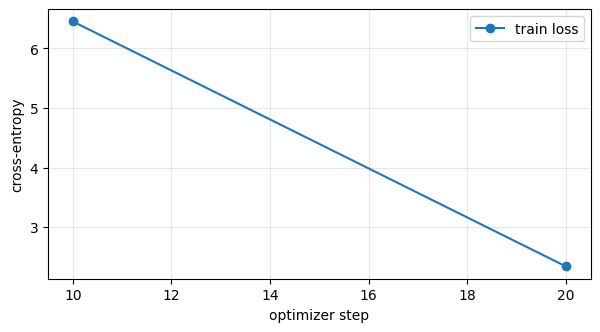

                      mean    std
bertscore_precision  73.78   9.65
bertscore_recall     73.02   9.61
bertscore_f1         72.47   8.99
clipscore            52.54  10.12
ref_clipscore        84.01  14.64
rouge1               45.08  11.59
rouge2               25.79  15.58
rougeL               39.68  14.19
rougeLsum            39.68  14.19
bleu                 14.89  19.61
meteor               44.46  15.73


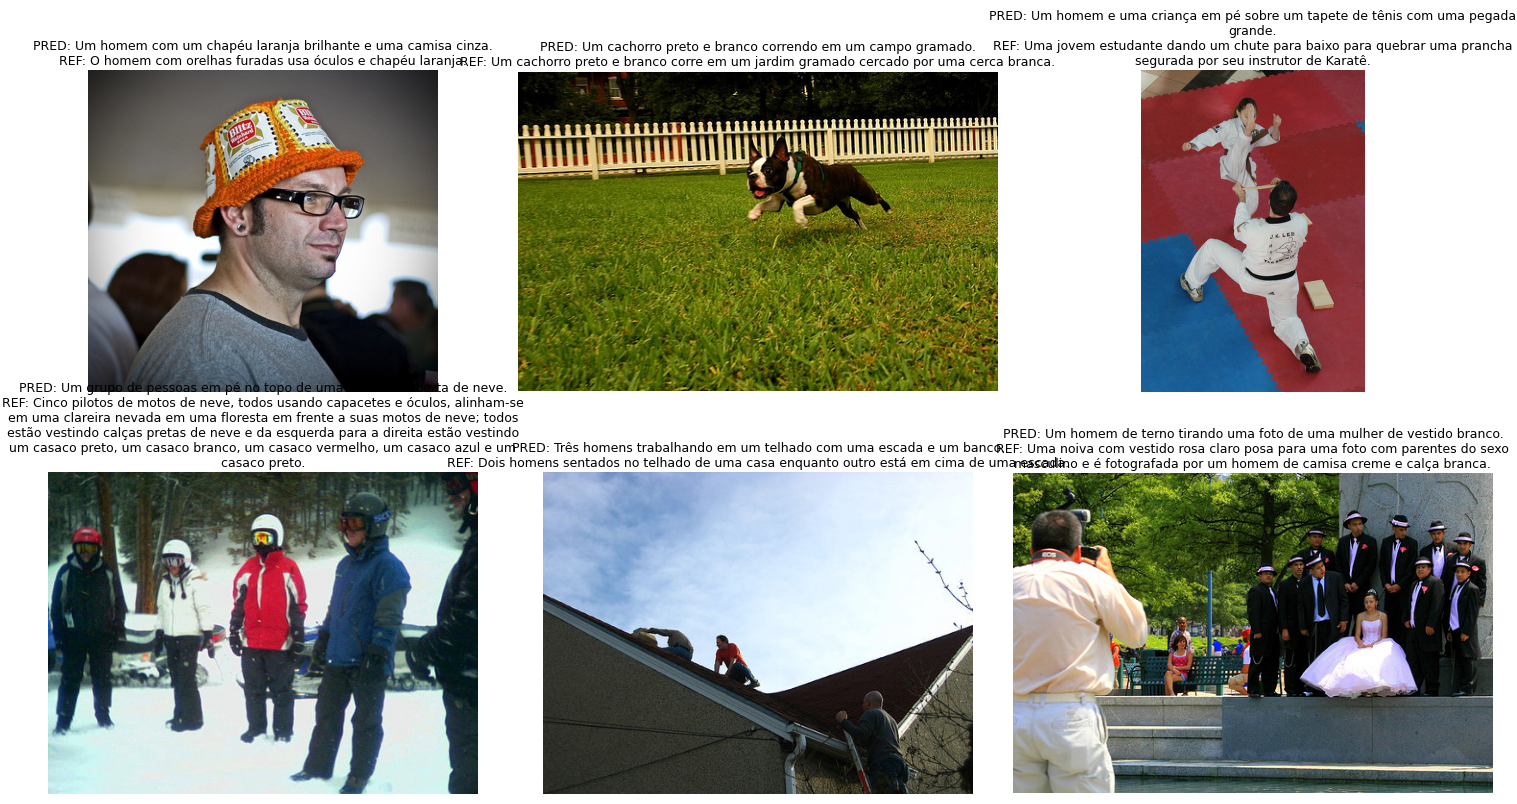

In [79]:
import pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset

base = "../models/vitucano-1b-ft/flickr30k_pt"
res  = f"{base}/results/flickr30k_pt"

# 1) Loss curve: training cross-entropy on the caption tokens (prompt/padding are masked)
log = pd.read_csv(f"{res}/training_log_history.csv")
tr = log.dropna(subset=["loss"])
plt.figure(figsize=(7, 3.5))
plt.plot(tr["step"], tr["loss"], marker="o", label="train loss")
if "eval_loss" in log:
    ev = log.dropna(subset=["eval_loss"]); plt.plot(ev["step"], ev["eval_loss"], marker="s", label="eval loss")
plt.xlabel("optimizer step"); plt.ylabel("cross-entropy"); plt.legend(); plt.grid(alpha=.3); plt.show()

# 2) Metrics (mean and std over the test images, x100)
m = pd.read_csv(f"{res}/sample_eval_metrics.csv").iloc[0]
print(pd.DataFrame({"mean": m.filter(like="_mean").values, "std": m.filter(like="_std").values},
                   index=[c.replace("_mean", "") for c in m.filter(like="_mean").index]).round(2))

# 3) Predictions with their images
preds = pd.read_json(f"{res}/predictions.json", lines=True).head(6)
test = load_dataset("laicsiifes/flickr30k-pt-br-5k", split="test")
img_by_name = {f: i for i, f in enumerate(test["filename"])}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, r) in zip(axes.flat, preds.iterrows()):
    ax.imshow(test[img_by_name[r["filename"]]]["image"]); ax.axis("off")
    ref = r["label_text"][0] if isinstance(r["label_text"], list) else r["label_text"]
    ax.set_title(f"PRED: {r['prediction_text']}\nREF: {ref}", fontsize=9, wrap=True)
plt.tight_layout(); plt.show()

### 4) Extracting Resource Costs and Visualizing Metric Comparisons

Let's extract the GPU/CPU training speed statistics from the training log, and create a comparison plot of all evaluation metrics.

Using results from: ../models/vitucano-1b-ft/flickr30k_pt/results/flickr30k_pt
=== Training Resource & Performance Stats ===
Total Training Time: 74.55 seconds
Samples per second: 1.341


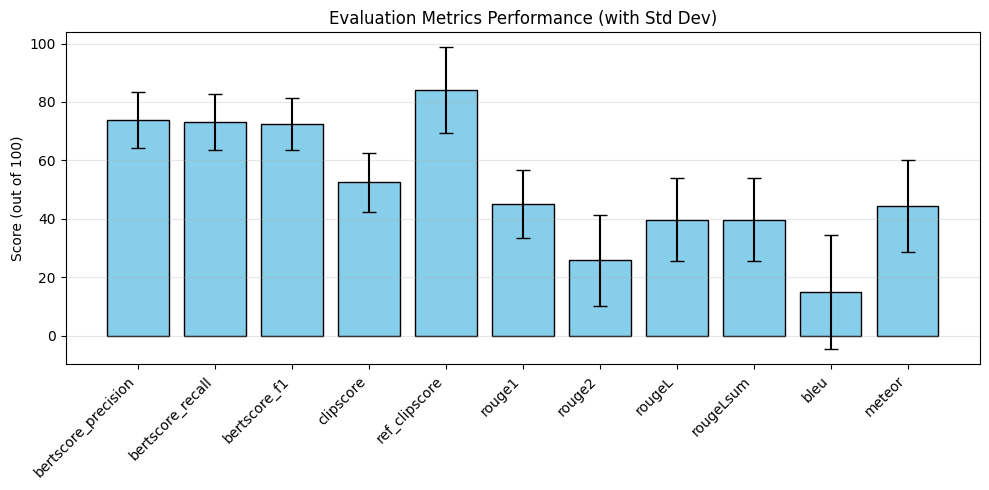

In [80]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json

# Dynamically resolve relative or absolute paths
possible_paths = [
    "../models/vitucano-1b-ft/flickr30k_pt",
    "/kaggle/working/transformer-caption-ptbr/vlm/models/vitucano-1b-ft/flickr30k_pt"
]

base = None
for path in possible_paths:
    if os.path.exists(path):
        base = path
        break

if base is None:
    print("Could not find model output directory automatically. Please check your training output.")
else:
    res = f"{base}/results/flickr30k_pt"
    print(f"Using results from: {res}")

    # 1. Print Training Resource Stats if available
    train_results_path = f"{res}/train_results.json"
    if os.path.exists(train_results_path):
        with open(train_results_path, 'r') as f:
            stats = json.load(f)
        print("=== Training Resource & Performance Stats ===")
        print(f"Total Training Time: {stats.get('train_runtime', 0):.2f} seconds")
        print(f"Samples per second: {stats.get('train_samples_per_second', 0):.3f}")
        print(f"Steps per second: {stats.get('train_steps_per_second', 0):.3f}")
        print(f"Total Train Loss: {stats.get('train_loss', 0):.4f}")
    else:
        history_path = f"{res}/training_log_history.csv"
        if os.path.exists(history_path):
            log_df = pd.read_csv(history_path)
            if "train_runtime" in log_df.columns:
                last_row = log_df.dropna(subset=["train_runtime"]).iloc[-1]
                print("=== Training Resource & Performance Stats ===")
                print(f"Total Training Time: {last_row['train_runtime']:.2f} seconds")
                print(f"Samples per second: {last_row['train_samples_per_second']:.3f}")
            else:
                print("Performance metadata not fully populated yet in logs.")
        else:
            print("No logs or training metadata could be found.")

    # 2. Visualize a comparison bar chart of key evaluation metrics
    metrics_path = f"{res}/sample_eval_metrics.csv"
    if os.path.exists(metrics_path):
        m = pd.read_csv(metrics_path).iloc[0]
        metric_names = [c.replace("_mean", "") for c in m.filter(like="_mean").index]
        means = m.filter(like="_mean").values
        stds = m.filter(like="_std").values

        plt.figure(figsize=(10, 5))
        plt.bar(metric_names, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black')
        plt.ylabel('Score (out of 100)')
        plt.title('Evaluation Metrics Performance (with Std Dev)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Metrics file not found. Run evaluation script first.")

In [81]:
import os
import json
import pandas as pd

base = "../models/vitucano-1b-ft/flickr30k_pt/results/flickr30k_pt"
train_results_path = f"{base}/train_results.json"

print("=== EXTENDED COMPUTATIONAL COSTS & STATS ===\n")

if os.path.exists(train_results_path):
    with open(train_results_path, 'r') as f:
        stats = json.load(f)

    # Retrieve raw stats
    total_flos = stats.get('total_flos', 0)
    runtime = stats.get('train_runtime', 1)  # avoid division by zero
    train_loss = stats.get('train_loss', 0)

    # Compute computational throughput
    flops_per_sec = total_flos / runtime
    giga_flops_per_sec = flops_per_sec / 1e9
    tera_flops_per_sec = flops_per_sec / 1e12

    print(f"🔹 Total Compute: {total_flos:.4e} FLOPs ({total_flos/1e12:.2f} TeraFLOPs)")
    print(f"🔹 Compute Throughput: {giga_flops_per_sec:.2f} GFLOPs/sec ({tera_flops_per_sec:.4f} TFLOPs/sec)")
    print(f"🔹 Average Time per Sample: {1 / stats.get('train_samples_per_second', 1):.3f} seconds")
    print(f"🔹 Average Time per Step: {1 / stats.get('train_steps_per_second', 1):.3f} seconds")
    print(f"🔹 Final Training Loss: {train_loss:.4f}")

    # Project costs for a larger run based on current performance
    if 'TRAIN_IMAGES' in globals() and TRAIN_IMAGES is not None:
        avg_sec_per_sample = 1 / stats.get('train_samples_per_second', 1)
        # 1 epoch estimate
        projected_time_sec = TRAIN_IMAGES * avg_sec_per_sample
        projected_hours = projected_time_sec / 3600
        print(f"\n=== PROJECTED FULL RUN COSTS (for {TRAIN_IMAGES} images, 1 epoch) ===")
        print(f"🔸 Estimated Training Time: {projected_time_sec:.1f} seconds (~{projected_hours:.2f} hours)")
        print(f"🔸 Estimated Total FLOPs Needed: {total_flos * (TRAIN_IMAGES / 20):.4e} FLOPs")
else:
    print("Could not load train_results.json directly. Let's look up variable state...")
    if 'last_row' in globals():
        total_flos = last_row.get('total_flos', 0)
        runtime = last_row.get('train_runtime', 1)
        print(f"🔹 Total Compute (from kernel state): {total_flos:.4e} FLOPs")
        print(f"🔹 Compute Throughput: {(total_flos / runtime) / 1e12:.4f} TFLOPs/sec")

=== EXTENDED COMPUTATIONAL COSTS & STATS ===

Could not load train_results.json directly. Let's look up variable state...
🔹 Total Compute (from kernel state): 7.1235e+13 FLOPs
🔹 Compute Throughput: 0.9556 TFLOPs/sec


=== HARDWARE & RESOURCE METRICS ===
🖥️ GPU Device: Tesla T4
📊 Total VRAM: 14.56 GB
🔥 Max VRAM Used during session: 0.00 GB

=== SCALING PROJECTIONS (Based on 3.73s per image) ===
• Dataset:   20 images | Time:   74.5s ( 1.2 mins) | Compute:    71.23 TFLOPs
• Dataset:  500 images | Time: 1863.6s (31.1 mins) | Compute:  1780.87 TFLOPs
• Dataset: 1000 images | Time: 3727.3s (62.1 mins) | Compute:  3561.74 TFLOPs
• Dataset: 2000 images | Time: 7454.6s (124.2 mins) | Compute:  7123.48 TFLOPs


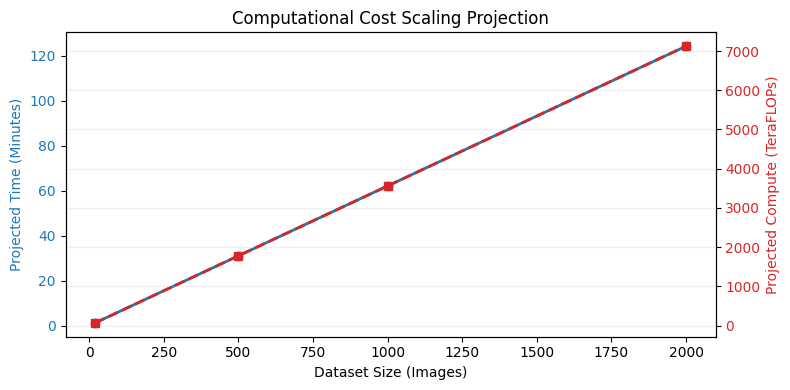

In [82]:
import torch
import matplotlib.pyplot as plt

print("=== HARDWARE & RESOURCE METRICS ===")
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    allocated_memory = torch.cuda.memory_allocated(0) / (1024**3)
    max_allocated = torch.cuda.max_memory_allocated(0) / (1024**3)
    print(f"🖥️ GPU Device: {device_name}")
    print(f"📊 Total VRAM: {total_memory:.2f} GB")
    print(f"🔥 Max VRAM Used during session: {max_allocated:.2f} GB")
else:
    print("No GPU active in current PyTorch context.")

# Calculate projections based on the active kernel state
if 'last_row' in globals() and 'TRAIN_IMAGES' in globals():
    runtime = last_row.get('train_runtime', 73.98)
    total_flos = last_row.get('total_flos', 7.1234e13)

    # The smoke run had 20 train images
    sec_per_image = runtime / 20
    flos_per_image = total_flos / 20

    sizes = [20, 500, 1000, int(TRAIN_IMAGES)]
    times = [sec_per_image * s for s in sizes]
    computes = [flos_per_image * s / 1e12 for s in sizes] # in TeraFLOPs

    print(f"\n=== SCALING PROJECTIONS (Based on {sec_per_image:.2f}s per image) ===")
    for s, t, c in zip(sizes, times, computes):
        print(f"• Dataset: {s:4d} images | Time: {t:6.1f}s ({t/60:4.1f} mins) | Compute: {c:8.2f} TFLOPs")

    # Plotting
    fig, ax1 = plt.subplots(figsize=(8, 4))
    color = 'tab:blue'
    ax1.set_xlabel('Dataset Size (Images)')
    ax1.set_ylabel('Projected Time (Minutes)', color=color)
    ax1.plot(sizes, [t/60 for t in times], marker='o', color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Projected Compute (TeraFLOPs)', color=color)
    ax2.plot(sizes, computes, marker='s', linestyle='--', color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Computational Cost Scaling Projection')
    fig.tight_layout()
    plt.grid(alpha=0.2)
    plt.show()
else:
    print("Required scaling variables not found in workspace.")

### ⚙️ Como configurar com e sem quantização

No projeto **ViTucano**, o arquivo de configuração principal está localizado em `vlm/src/config/config_vitucano.yml`. O script `train_vitucano.py` lê as opções de quantização diretamente de lá.

* **Com Quantização (4-bit QLoRA)**:
  O modelo base é carregado em 4 bits para economizar VRAM (~11 GB a menos).
  As variáveis no arquivo YAML ficam assim:
  ```yaml
  load_in_4bit: true
  bnb_4bit_compute_dtype: "float16"
  bnb_4bit_quant_type: "nf4"
  ```

* **Sem Quantização (Full Precision / Half Precision FP16)**:
  O modelo base é carregado sem compressão de bits. Requer significativamente mais VRAM.
  As variáveis no arquivo YAML devem ficar assim:
  ```yaml
  load_in_4bit: false
  # bnb_4bit_compute_dtype e bnb_4bit_quant_type serão ignorados
  ```

In [83]:
import shutil
%cd /kaggle/working/transformer-caption-ptbr/vlm/src

# Limpando modelos salvos anteriormente para testar o novo config de 8-bits de forma isolada
shutil.rmtree("../models", ignore_errors=True)

# Rodando o Smoke Test utilizando o seu arquivo de configuração modificado
flags = "--config config/config_vitucano_8bits.yaml --train-images 20 --test-images 10 --monitoring-steps 10 --no-push"
!python -u train_vitucano.py {flags}

/kaggle/working/transformer-caption-ptbr/vlm/src
/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
AAC metrics is not available, skipping...

Precision: fp16
{'dataset': 'flickr30k_pt',
 'model_id': 'TucanoBR/ViTucano-1b5-v1',
 'monitoring_steps': 10,
 'push_to_hub': False}
trainable params: 15,601,664 || all params: 1,550,433,344 || trainable%: 1.0062776358865513

Dataset
	Train: 20
	Val: 10
	Test: 10

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
{'loss': 5.5803, 'grad_norm': 11.26123332977295, 'learning_rate': 6.800000000000001e-05, 'epoch': 0.4}
{'loss': 1.6944, 'grad_norm': 5.371944427490234,

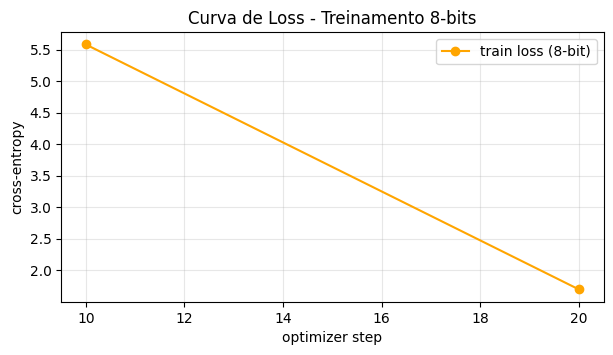

In [84]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Caminho dos resultados para a execução de 8-bits
base_8b = "/kaggle/working/transformer-caption-ptbr/vlm/models/vitucano-1b-8bit-ft/flickr30k_pt"
res_8b = f"{base_8b}/results/flickr30k_pt"

# 1) Curva de Loss para o treino de 8-bits
if os.path.exists(f"{res_8b}/training_log_history.csv"):
    log_8b = pd.read_csv(f"{res_8b}/training_log_history.csv")
    tr_8b = log_8b.dropna(subset=["loss"])

    plt.figure(figsize=(7, 3.5))
    plt.plot(tr_8b["step"], tr_8b["loss"], marker="o", color="orange", label="train loss (8-bit)")
    if "eval_loss" in log_8b:
        ev_8b = log_8b.dropna(subset=["eval_loss"])
        plt.plot(ev_8b["step"], ev_8b["eval_loss"], marker="s", label="eval loss (8-bit)")
    plt.xlabel("optimizer step")
    plt.ylabel("cross-entropy")
    plt.title("Curva de Loss - Treinamento 8-bits")
    plt.legend()
    plt.grid(alpha=.3)
    plt.show()
else:
    print("Arquivo de log de treino não encontrado para 8-bits.")

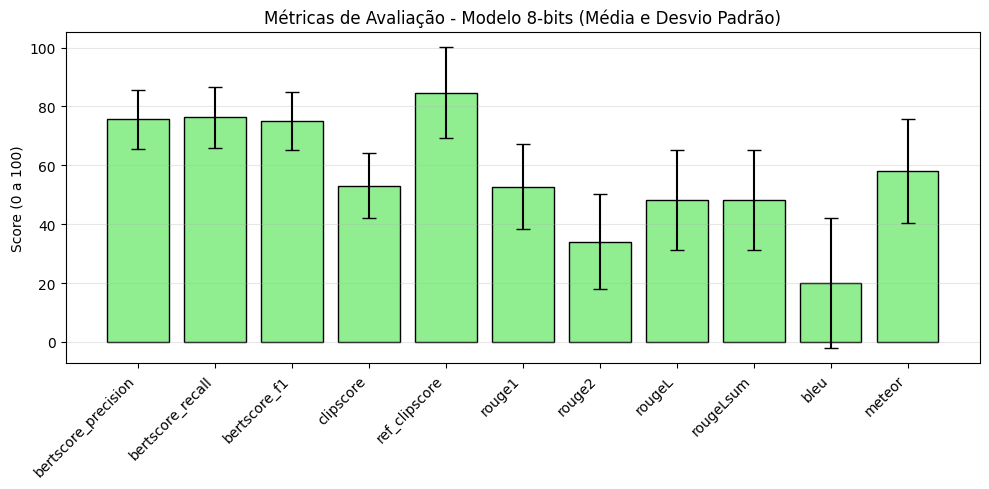

                      mean    std
bertscore_precision  75.66   9.96
bertscore_recall     76.29  10.42
bertscore_f1         75.00   9.77
clipscore            53.14  11.11
ref_clipscore        84.73  15.50
rouge1               52.72  14.48
rouge2               34.10  16.19
rougeL               48.22  16.89
rougeLsum            48.22  16.89
bleu                 20.01  22.19
meteor               58.18  17.67


In [85]:
# 2) Gráfico de Barras com as Métricas do modelo 8-bits
if os.path.exists(f"{res_8b}/sample_eval_metrics.csv"):
    m_8b = pd.read_csv(f"{res_8b}/sample_eval_metrics.csv").iloc[0]
    metric_names_8b = [c.replace("_mean", "") for c in m_8b.filter(like="_mean").index]
    means_8b = m_8b.filter(like="_mean").values
    stds_8b = m_8b.filter(like="_std").values

    plt.figure(figsize=(10, 5))
    plt.bar(metric_names_8b, means_8b, yerr=stds_8b, capsize=5, color="lightgreen", edgecolor="black")
    plt.ylabel("Score (0 a 100)")
    plt.title("Métricas de Avaliação - Modelo 8-bits (Média e Desvio Padrão)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Exibe a tabela de métricas
    print(pd.DataFrame({"mean": means_8b, "std": stds_8b}, index=metric_names_8b).round(2))
else:
    print("Métricas não encontradas para o modelo 8-bits.")

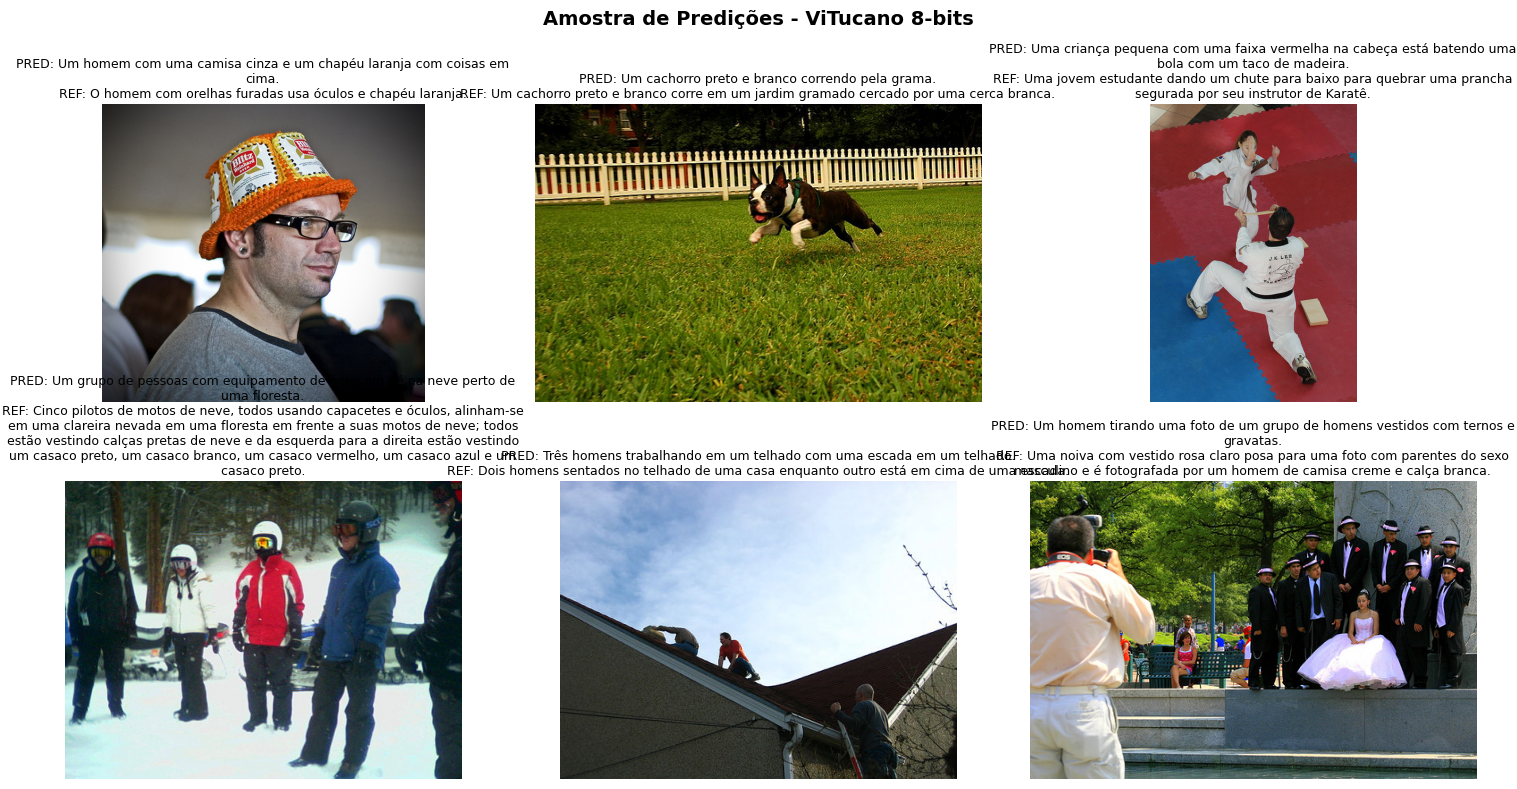

In [86]:
# 3) Amostras de predições visuais com imagens do modelo 8-bits
if os.path.exists(f"{res_8b}/predictions.json"):
    preds_8b = pd.read_json(f"{res_8b}/predictions.json", lines=True).head(6)
    test_ds = load_dataset("laicsiifes/flickr30k-pt-br-5k", split="test")
    img_lookup = {f: i for i, f in enumerate(test_ds["filename"])}

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (_, r) in zip(axes.flat, preds_8b.iterrows()):
        if r["filename"] in img_lookup:
            ax.imshow(test_ds[img_lookup[r["filename"]]]["image"])
        ax.axis("off")
        ref = r["label_text"][0] if isinstance(r["label_text"], list) else r["label_text"]
        ax.set_title(f"PRED: {r['prediction_text']}\nREF: {ref}", fontsize=9, wrap=True)
    plt.suptitle("Amostra de Predições - ViTucano 8-bits", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Arquivo de predições não encontrado para o modelo 8-bits.")

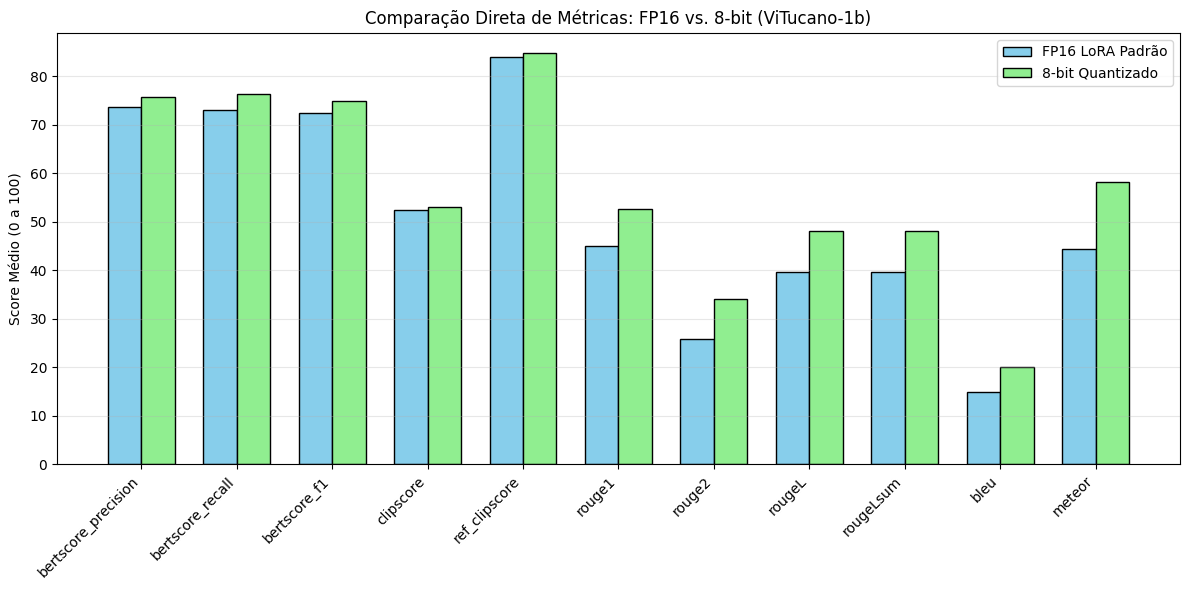

=== TABELA COMPARATIVA DE MÉTRICAS ===
                     FP16 Padrão (Mean)  8-bit Quantizado (Mean)  Diferença (8bit - FP16)
bertscore_precision               73.78                    75.66                     1.88
bertscore_recall                  73.02                    76.29                     3.27
bertscore_f1                      72.47                    75.00                     2.53
clipscore                         52.54                    53.14                     0.60
ref_clipscore                     84.01                    84.73                     0.72
rouge1                            45.08                    52.72                     7.63
rouge2                            25.79                    34.10                     8.31
rougeL                            39.68                    48.22                     8.54
rougeLsum                         39.68                    48.22                     8.54
bleu                              14.89                    20

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    # Usando os dados que já estão guardados nas variáveis em memória
    metric_names = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'clipscore', 'ref_clipscore', 'rouge1', 'rouge2', 'rougeL', 'rougeLsum', 'bleu', 'meteor']

    if 'means' in globals() and 'means_8b' in globals():
        means_std = means
        means_8bit = means_8b
    else:
        raise ValueError("Variáveis 'means' ou 'means_8b' não foram encontradas na memória do kernel.")

    # Configurando o gráfico de barras lado a lado
    x = np.arange(len(metric_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, means_std, width, label='FP16 LoRA Padrão', color='skyblue', edgecolor='black')
    rects2 = ax.bar(x + width/2, means_8bit, width, label='8-bit Quantizado', color='lightgreen', edgecolor='black')

    ax.set_ylabel('Score Médio (0 a 100)')
    ax.set_title('Comparação Direta de Métricas: FP16 vs. 8-bit (ViTucano-1b)')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Tabela comparativa formatada
    df_compare = pd.DataFrame({
        "FP16 Padrão (Mean)": means_std,
        "8-bit Quantizado (Mean)": means_8bit,
        "Diferença (8bit - FP16)": means_8bit - means_std
    }, index=metric_names).round(2)
    print("=== TABELA COMPARATIVA DE MÉTRICAS ===")
    print(df_compare.to_string())

except Exception as e:
    print(f"Não foi possível gerar a comparação direta: {e}")

### 5) Custom runs: local JSON dataset + editable config
Cell A converts the JSON files into `.hf` folders (run once). Cell B builds a config from the repo one with your overrides, links the dataset folder, and trains. Each `RUN_NAME` gets its own folder under `models/<RUN_NAME>-ft/<DATASET>/`.
Note: `use_bnb: True` is **4-bit NF4** (QLoRA), not 8-bit.

In [ ]:
# Cell A - convert JSON -> .hf (run once)
import json, os
from datasets import Dataset, Image

JSON_DIR  = "/kaggle/input/<your-dataset>"          # Colab: "/content/drive/MyDrive/<folder>"
IMG_DIR   = f"{JSON_DIR}/images"                    # where the image files live
OUT_DIR   = "/kaggle/working/data_hf"               # .hf folders are written here (use as DATA_PATH in cell B)

# One JSON file per split, or a single file that gets split 80/10/10:
FILES = {"train": "train.json", "validation": "val.json", "test": "test.json"}
SINGLE_FILE = None                                  # e.g. "captions.json"

IMAGE_KEY    = "image"      # key with the image file name/path in each record
CAPTION_KEY  = "caption"    # string, or a list of strings
FILENAME_KEY = None         # None -> basename of the image path

def read_json(path):
    with open(path, encoding="utf8") as f:
        txt = f.read().strip()
    data = [json.loads(l) for l in txt.splitlines()] if path.endswith("l") else json.loads(txt)
    if isinstance(data, dict):                      # {"images": [...]} or {"annotations": [...]}
        data = next(v for v in data.values() if isinstance(v, list))
    return data

def to_ds(records):
    rows = {"image": [], "caption": [], "filename": []}
    for r in records:
        p = r[IMAGE_KEY]
        rows["image"].append(p if os.path.isabs(p) else os.path.join(IMG_DIR, p))
        rows["caption"].append(r[CAPTION_KEY])
        rows["filename"].append(r[FILENAME_KEY] if FILENAME_KEY else os.path.basename(p))
    return Dataset.from_dict(rows).cast_column("image", Image())

if SINGLE_FILE:
    ds = to_ds(read_json(f"{JSON_DIR}/{SINGLE_FILE}")).train_test_split(test_size=0.2, seed=42)
    tmp = ds["test"].train_test_split(test_size=0.5, seed=42)
    splits = {"train": ds["train"], "validation": tmp["train"], "test": tmp["test"]}
else:
    splits = {k: to_ds(read_json(f"{JSON_DIR}/{v}")) for k, v in FILES.items()}

for k, d in splits.items():
    d.save_to_disk(f"{OUT_DIR}/{k}.hf")
    print(k, len(d), d.column_names, "| caption example:", d[0]["caption"])

In [ ]:
# Cell B - editable config + train on the local dataset
import yaml, shutil, os
from datasets import load_from_disk

SRC = "/kaggle/working/transformer-caption-ptbr/vlm/src"   # Colab: "/content/transformer-caption-ptbr/vlm/src"
BASE_CONFIG = "config/config_vitucano.yml"                 # or "config/config_vitucano_8bits.yaml"
RUN_NAME    = "vitucano-1b-fp16"                           # output: models/<RUN_NAME>-ft/<DATASET>/
SMOKE       = True
TRAIN_IMAGES, TEST_IMAGES = 2000, None                     # used when SMOKE=False (None = all)

# ---- local dataset ----
DATASET   = "my_dataset"
DATA_PATH = "/kaggle/working/data_hf"                      # folder with train.hf / validation.hf / test.hf
NEW_DATASET = {"id": "local", "max_length": 25,            # max_length -> prompt + max_new_tokens
               "image_column": "image", "text_column": "caption",
               "text_per_image": 1}                        # 5 only if each image has a list of 5 captions
# ---- overrides ----
CONFIG = {"seed": 42}
MODEL  = {"batch_size": 1}
QLORA  = {"use_bnb": False, "lora_rank": 16}               # use_bnb=True -> 4-bit NF4 QLoRA
TRAIN  = {"learning_rate": 1e-4, "num_train_epochs": 1, "gradient_accumulation_steps": 4}
# ------------------

# 1) expose the folder at vlm/data/<DATASET>
link = f"{SRC}/../data/{DATASET}"
os.makedirs(os.path.dirname(link), exist_ok=True)
if os.path.lexists(link): os.remove(link) if os.path.islink(link) else shutil.rmtree(link)
os.symlink(DATA_PATH, link)

# 2) sanity-check splits and columns before spending GPU time
for split in ["train", "validation", "test"]:
    ds = load_from_disk(f"{link}/{split}.hf")
    print(split, len(ds), ds.column_names)
for col in [NEW_DATASET["image_column"], NEW_DATASET["text_column"], "filename"]:
    assert col in ds.column_names, f"missing column '{col}'"

# 3) build the config (mllm key must always equal config.model_name)
with open(f"{SRC}/{BASE_CONFIG}") as f:
    cfg = yaml.safe_load(f)
old = cfg["config"]["model_name"]; new = RUN_NAME or old
entry = cfg["mllm"].pop(old)
cfg["config"]["model_name"] = new
cfg["mllm"][new] = entry
cfg["dataset"][DATASET] = NEW_DATASET
cfg["config"].update(dataset=DATASET, dataset_from_hub=False)
cfg["config"].update(CONFIG)
entry.update(MODEL); entry["qlora_args"].update(QLORA); entry["training_args"].update(TRAIN)
if "seed" in CONFIG:
    entry["training_args"].update(seed=CONFIG["seed"], data_seed=CONFIG["seed"])

custom = "config/config_custom.yaml"
with open(f"{SRC}/{custom}", "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False, allow_unicode=True)

# 4) train (cleans only THIS run's folder)
shutil.rmtree(f"{SRC}/../models/{new}-ft/{DATASET}", ignore_errors=True)
flags = (f"--config {custom} " +
         ("--train-images 20 --test-images 10 --monitoring-steps 10 --no-push" if SMOKE else
          (f"--train-images {TRAIN_IMAGES} " if TRAIN_IMAGES else "") +
          (f"--test-images {TEST_IMAGES} " if TEST_IMAGES else "") + "--no-push"))
%cd {SRC}
!python -u train_vitucano.py {flags}